# Classical time-series statistics by hand (no statsmodels)

Everything is computed with NumPy and pandas so you can see what a library would do.
Every idea is shown first on a series of 6–12 numbers you can check by eye, then on the
real hourly consumption / price data.

**What's in here**
1. autocorrelation (ACF) by hand, the white-noise band
2. partial autocorrelation (PACF) via a small regression
3. stationarity: rolling moments, variance ratio, differencing, log transform
4. seasonal decomposition by hand (trend / seasonal / residual)
5. AR models via OLS; one-step vs multi-step forecasts
6. exponential smoothing step by step
7. cross-correlation and lead–lag (which series leads?)
8. spurious regression of two random walks
9. volatility clustering
10. error vs forecast horizon

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
%matplotlib inline

pd.set_option("display.width", 120)
np.set_printoptions(precision=4, suppress=True)

df = pd.read_csv("../data/hourly_power_clean.csv", parse_dates=["time"]).set_index("time")
cons = df["consumption_mwh"]
price = df["price_eur_mwh"]
temp = df["temp_c"]
print(len(cons), "hours from", cons.index.min(), "to", cons.index.max())

17520 hours from 2022-01-01 00:00:00+00:00 to 2023-12-31 23:00:00+00:00


## 1. Autocorrelation at lag 1, by hand

Autocorrelation at lag 1 is the correlation between the series and itself shifted by one step.
Six values:

In [2]:
x = pd.Series([2, 4, 6, 8, 6, 4])
x

0    2
1    4
2    6
3    8
4    6
5    4
dtype: int64

In [3]:
lagged = x.shift(1)
pd.DataFrame({"x_t": x, "x_t-1": lagged})

,x_t,x_t-1
0,2,NaN
1,4,2.0
2,6,4.0
3,8,6.0
4,6,8.0
5,4,6.0


Row 0 has no previous value → NaN. Drop it and correlate the two columns.

In [4]:
pair = pd.DataFrame({"x_t": x, "x_t-1": lagged}).dropna()
pair

,x_t,x_t-1
1,4,2.0
2,6,4.0
3,8,6.0
4,6,8.0
5,4,6.0


In [5]:
r1 = np.corrcoef(pair["x_t"], pair["x_t-1"])[0, 1]
print("lag-1 autocorrelation:", round(r1, 4))

lag-1 autocorrelation: 0.4193


That is the `corrcoef` version: it re-centres each column with its own mean.
The **standard ACF** used by every library uses one mean (the mean of the whole series)
and divides by the total sum of squares. Same idea, slightly different arithmetic:

In [6]:
xc = x - x.mean()                    # centre once, with the overall mean
print("centred values:", xc.values)
numerator = (xc[1:].values * xc[:-1].values).sum()    # products of neighbours
denominator = (xc ** 2).sum()                          # total sum of squares
print("numerator  :", numerator)
print("denominator:", denominator)
print("ACF(1)     :", round(numerator / denominator, 4))

centred values: [-3. -1.  1.  3.  1. -1.]
numerator  : 7.0
denominator: 22.0
ACF(1)     : 0.3182


The two numbers differ (0.42 vs 0.32) because the series is short: with 6 values, the
"neighbours" columns have different means from the whole series. On thousands of points
the two agree closely. Know which one you computed.

Now wrap the standard version in a function so we can ask for many lags at once.

In [7]:
def acf(series, nlags):
    xc = np.asarray(series, dtype=float)
    xc = xc - xc.mean()
    denominator = (xc ** 2).sum()
    out = [1.0]                                       # lag 0 is always 1
    for k in range(1, nlags + 1):
        numerator = (xc[k:] * xc[:-k]).sum()
        out.append(numerator / denominator)
    return np.array(out)

acf(x, 3)

array([ 1.    ,  0.3182, -0.3636, -0.5   ])

### On the real data

Consumption repeats every 24 hours and every 168 hours (a week), so the ACF has peaks there.

In [8]:
r = acf(cons, 200)
pd.Series(r[[1, 2, 12, 24, 48, 168]], index=[1, 2, 12, 24, 48, 168], name="ACF").round(3)

1      0.935
2      0.781
12    -0.047
24     0.913
48     0.866
168    0.920
Name: ACF, dtype: float64

white-noise band: ± 0.0148


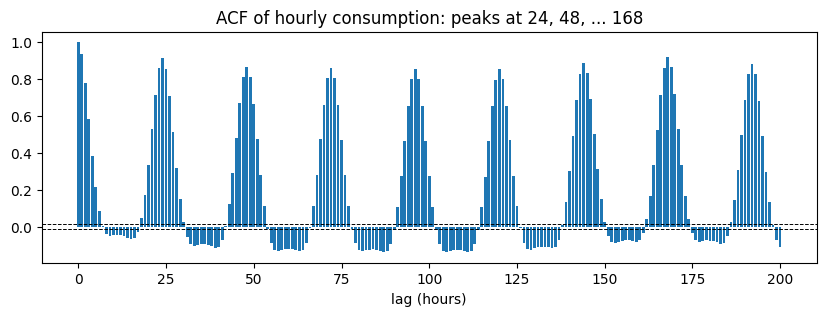

In [9]:
n = len(cons)
band = 1.96 / np.sqrt(n)
print("white-noise band: ±", round(band, 4))

fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(range(201), r, width=0.8)
ax.axhline(band, color="k", lw=0.7, ls="--")
ax.axhline(-band, color="k", lw=0.7, ls="--")
ax.set_title("ACF of hourly consumption: peaks at 24, 48, ... 168")
ax.set_xlabel("lag (hours)")
plt.show()

**Pitfall:** the ±1.96/√n band is the standard error of a sample autocorrelation **if the
series were white noise**. For a strongly autocorrelated series the true standard error
at higher lags is bigger, so "lag 50 is outside the band" does not mean lag 50 matters on
its own.

**Interview check:** "Why does the ACF decay so slowly?" Levels of hourly load are
dominated by the daily cycle and slow weather. The ACF of the *levels* shows seasonality;
the ACF of the *residuals after removing the cycle* shows what you still need to model.

## 2. Partial autocorrelation (PACF) via a small regression

PACF at lag 2 answers: "what does lag 2 add once lag 1 is already in?"
It is the coefficient on `x_t-2` in a regression of `x_t` on `x_t-1` and `x_t-2`.

Ten values:

In [10]:
x = pd.Series([1.0, 3.0, 2.0, 4.0, 3.0, 5.0, 4.0, 6.0, 5.0, 7.0])
tbl = pd.DataFrame({"x_t": x, "x_t-1": x.shift(1), "x_t-2": x.shift(2)})
tbl

,x_t,x_t-1,x_t-2
0,1.0,NaN,NaN
1,3.0,1.0,NaN
2,2.0,3.0,1.0
3,4.0,2.0,3.0
4,3.0,4.0,2.0
5,5.0,3.0,4.0
6,4.0,5.0,3.0
7,6.0,4.0,5.0
8,5.0,6.0,4.0
9,7.0,5.0,6.0


In [11]:
tbl = tbl.dropna()
y = tbl["x_t"].values
X = np.column_stack([np.ones(len(tbl)), tbl["x_t-1"].values, tbl["x_t-2"].values])
print("design matrix X (intercept, x_t-1, x_t-2):")
print(X)
print("target y:", y)

design matrix X (intercept, x_t-1, x_t-2):
[[1. 3. 1.]
 [1. 2. 3.]
 [1. 4. 2.]
 [1. 3. 4.]
 [1. 5. 3.]
 [1. 4. 5.]
 [1. 6. 4.]
 [1. 5. 6.]]
target y: [2. 4. 3. 5. 4. 6. 5. 7.]


In [12]:
beta, *_ = np.linalg.lstsq(X, y, rcond=None)
print("coefficients [intercept, lag1, lag2]:", beta.round(3))
print("PACF(2) = coefficient on lag 2 =", round(beta[2], 3))

coefficients [intercept, lag1, lag2]: [1. 0. 1.]
PACF(2) = coefficient on lag 2 = 1.0


The pattern 1,3,2,4,3,5,... is "two steps back plus 2", so lag 2 gets a coefficient near 1
and lag 1 near 0.

For PACF(k) repeat this with lags 1..k and keep the last coefficient. Wrapped in a loop:

In [13]:
def pacf(series, nlags):
    s = pd.Series(np.asarray(series, dtype=float))
    out = [1.0]
    for k in range(1, nlags + 1):
        cols = {}
        for j in range(1, k + 1):
            cols["lag" + str(j)] = s.shift(j)
        d = pd.DataFrame(cols)
        d["y"] = s
        d = d.dropna()
        X = np.column_stack([np.ones(len(d))] + [d["lag" + str(j)].values for j in range(1, k + 1)])
        beta, *_ = np.linalg.lstsq(X, d["y"].values, rcond=None)
        out.append(beta[-1])                      # coefficient on the last lag
    return np.array(out)

pacf(x, 3).round(3)

array([ 1.   ,  0.5  ,  1.   , -0.333])

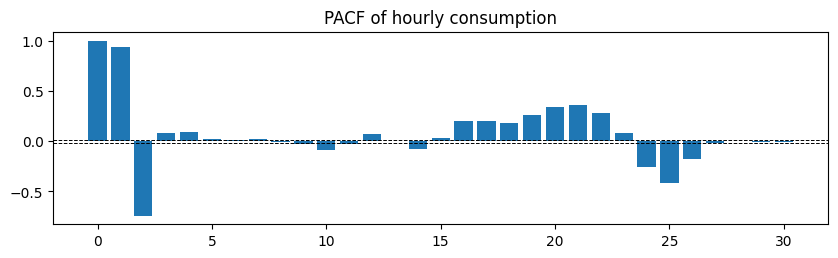

PACF lags 1..4 : [ 0.935 -0.739  0.078  0.09 ]
PACF lag 24, 25: -0.253 -0.411


In [14]:
p = pacf(cons, 30)
fig, ax = plt.subplots(figsize=(10, 2.5))
ax.bar(range(31), p, width=0.8)
ax.axhline(band, color="k", ls="--", lw=0.7)
ax.axhline(-band, color="k", ls="--", lw=0.7)
ax.set_title("PACF of hourly consumption")
plt.show()
print("PACF lags 1..4 :", p[1:5].round(3))
print("PACF lag 24, 25:", p[24].round(3), p[25].round(3))

Lag 1 explains most; lag 2 is strongly negative (the series is smoother than an AR(1));
lag 24 still adds something after all shorter lags: the daily cycle.

## 3. Stationarity: does the series "wander"?

A stationary series has a mean and variance that do not drift. Two simulated series:
white noise, and its running sum (a random walk). First 8 rows:

In [15]:
rng = np.random.default_rng(0)
noise = pd.Series(rng.normal(size=2000))
random_walk = noise.cumsum()
pd.DataFrame({"noise": noise, "random_walk": random_walk}).head(8).round(2)

,noise,random_walk
0,0.13,0.13
1,-0.13,-0.01
2,0.64,0.63
3,0.10,0.74
4,-0.54,0.20
5,0.36,0.56
6,1.30,1.87
7,0.95,2.82


### Variance ratio

For a random walk the variance of a k-step change grows like k. For a stationary series it
does not. The 1-step and 2-step changes of the random walk (first 8 rows):

In [16]:
change1 = random_walk.diff(1)
change2 = random_walk.diff(2)
pd.DataFrame({"random_walk": random_walk, "1-step change": change1, "2-step change": change2}).head(8).round(2)

,random_walk,1-step change,2-step change
0,0.13,NaN,NaN
1,-0.01,-0.13,NaN
2,0.63,0.64,0.51
3,0.74,0.10,0.75
4,0.20,-0.54,-0.43
5,0.56,0.36,-0.17
6,1.87,1.30,1.67
7,2.82,0.95,2.25


In [17]:
v1 = change1.var()
v2 = change2.var()
print("var of 1-step changes:", round(v1, 3))
print("var of 2-step changes:", round(v2, 3))
print("variance ratio VR(2) = v2 / (2 * v1) =", round(v2 / (2 * v1), 3))

var of 1-step changes: 1.001
var of 2-step changes: 1.987
variance ratio VR(2) = v2 / (2 * v1) = 0.992


In [18]:
n1 = noise.diff(1).var()
n2 = noise.diff(2).var()
print("same for the white noise: VR(2) =", round(n2 / (2 * n1), 3))

same for the white noise: VR(2) = 0.5


VR ≈ 1 says "random walk"; white noise gives 0.5; anything well below 1 is mean-reverting.
On the real data:

In [19]:
rows = {}
for name, s in [("consumption", cons), ("price", price)]:
    v1 = s.diff(1).var()
    row = {}
    for k in [2, 6, 24, 168]:
        row[k] = s.diff(k).var() / (k * v1)
    rows[name] = row
pd.DataFrame(rows).T.round(2)

,2,6,24,168
consumption,1.68,2.35,0.05,0.01
price,0.71,0.50,0.06,0.01


Consumption is above 1 at short horizons (a smooth ramp: consecutive changes go the same
way) and collapses toward 0 at 24 and 168 hours: it returns to its daily cycle instead of
wandering. Price is below 1 everywhere: hourly changes mean-revert.

### Differencing

`diff(1)` removes a level, `diff(k)` removes a pattern that repeats every k steps.
Six values with a period-3 pattern on top of a rising level:

In [20]:
s = pd.Series([10, 12, 11, 13, 15, 14], dtype=float)
pd.DataFrame({"s": s, "diff(1)": s.diff(1), "diff(3)": s.diff(3)})

,s,diff(1),diff(3)
0,10.0,NaN,NaN
1,12.0,2.0,NaN
2,11.0,-1.0,NaN
3,13.0,2.0,3.0
4,15.0,2.0,3.0
5,14.0,-1.0,3.0


`diff(3)` is constant (3) because the pattern repeats every 3 steps and the level rises by
3 each cycle. `diff(1)` still shows the pattern.

**Pitfall (over-differencing):** differencing pure noise *creates* autocorrelation of
about −0.5 at lag 1.

In [21]:
white = pd.Series(np.random.default_rng(1).normal(size=5000))
print("ACF(1) of white noise        :", round(acf(white, 1)[1], 3))
print("ACF(1) of diff(1) white noise:", round(acf(white.diff().dropna(), 1)[1], 3))

ACF(1) of white noise        : -0.007
ACF(1) of diff(1) white noise: -0.503


In [22]:
rows = {}
for name, s in [("levels", cons), ("diff1", cons.diff(1)), ("diff24", cons.diff(24)), ("diff24 then diff1", cons.diff(24).diff(1))]:
    r = acf(s.dropna(), 168)
    rows[name] = {"acf1": r[1], "acf2": r[2], "acf24": r[24], "acf168": r[168]}
pd.DataFrame(rows).T.round(3)

,acf1,acf2,acf24,acf168
levels,0.935,0.781,0.913,0.920
diff1,0.682,0.337,0.861,0.875
diff24,0.896,0.806,-0.226,0.411
diff24 then diff1,-0.069,-0.059,-0.452,0.160


### Log transform

If the seasonal swing scales with the level, model `log(x)`. Impossible when values can be
≤ 0, which is the case for power prices.

**Pitfall:** `np.log` of a negative number gives NaN silently. Count non-positives first.

In [23]:
print("non-positive prices:", (price <= 0).sum())
log_price = np.log(price.where(price > 0))
print("NaN after log      :", log_price.isna().sum())

non-positive prices: 43
NaN after log      : 43


In [24]:
by_year = pd.DataFrame({
    "std of price": price.groupby(price.index.year).std(),
    "std of log price": log_price.groupby(log_price.index.year).std(),
}).round(3)
by_year

,std of price,std of log price
time,,
2022,33.827,0.324
2023,34.642,0.487


The log transform makes the two years *less* comparable: 2023 has a lower level with similar
absolute swings, so its log-volatility is higher. A transform is a modelling claim; check it.

## 4. Seasonal decomposition by hand

observed = trend + seasonal + residual.
Twelve values with a pattern that repeats every 4 steps on top of a slowly rising level:

In [25]:
obs = pd.Series([10, 14, 12, 8, 11, 15, 13, 9, 12, 16, 14, 10], dtype=float)
obs

0     10.0
1     14.0
2     12.0
3      8.0
4     11.0
5     15.0
6     13.0
7      9.0
8     12.0
9     16.0
10    14.0
11    10.0
dtype: float64

**Step 1 – trend:** a centred moving average over one full period (4) averages away the pattern.

In [26]:
trend = obs.rolling(4, center=True).mean()
pd.DataFrame({"observed": obs, "trend": trend})

,observed,trend
0,10.0,NaN
1,14.0,NaN
2,12.0,11.00
3,8.0,11.25
4,11.0,11.50
5,15.0,11.75
6,13.0,12.00
7,9.0,12.25
8,12.0,12.50
9,16.0,12.75


**Step 2 – seasonal:** subtract the trend, then average by position in the cycle (0,1,2,3).

In [27]:
detrended = obs - trend
position = pd.Series(np.arange(12) % 4)
seasonal_means = detrended.groupby(position).mean()
print("mean detrended value by position in the cycle:")
print(seasonal_means.round(3))

mean detrended value by position in the cycle:
0   -0.50
1    3.25
2    1.00
3   -3.25
dtype: float64


In [28]:
seasonal = position.map(seasonal_means)
residual = obs - trend - seasonal
pd.DataFrame({"observed": obs, "trend": trend, "position": position,
              "seasonal": seasonal, "residual": residual}).round(3)

,observed,trend,position,seasonal,residual
0,10.0,NaN,0,-0.50,NaN
1,14.0,NaN,1,3.25,NaN
2,12.0,11.00,2,1.00,0.0
3,8.0,11.25,3,-3.25,0.0
4,11.0,11.50,0,-0.50,0.0
5,15.0,11.75,1,3.25,0.0
6,13.0,12.00,2,1.00,0.0
7,9.0,12.25,3,-3.25,0.0
8,12.0,12.50,0,-0.50,0.0
9,16.0,12.75,1,3.25,0.0


The residual is tiny everywhere: the toy series really is trend + period-4 pattern.
(The first and last rows are NaN because the centred window has nothing to average there.)

### On the real data

Same three steps with a window of one week (168 hours) and a seasonal key of (day-of-week, hour).

In [29]:
trend_c = cons.rolling(168, center=True).mean()
detr_c = cons - trend_c
dow_hour = [cons.index.dayofweek, cons.index.hour]
seasonal_c = detr_c.groupby(dow_hour).transform("mean")
resid_c = detr_c - seasonal_c
dec = pd.DataFrame({"observed": cons, "trend": trend_c, "seasonal": seasonal_c, "residual": resid_c})
dec.loc["2023-01-10 00:00":"2023-01-10 05:00"].round(0)

,observed,trend,seasonal,residual
time,,,,
2023-01-10 00:00:00+00:00,28411.0,32029.0,-3300.0,-318.0
2023-01-10 01:00:00+00:00,27240.0,32013.0,-4349.0,-425.0
2023-01-10 02:00:00+00:00,27330.0,31999.0,-4907.0,237.0
2023-01-10 03:00:00+00:00,26684.0,31981.0,-5134.0,-162.0
2023-01-10 04:00:00+00:00,26630.0,31969.0,-4830.0,-509.0
2023-01-10 05:00:00+00:00,28318.0,31958.0,-3753.0,113.0


standard deviation of each part:
observed    4208.0
trend       1891.0
seasonal    3612.0
residual     998.0
dtype: float64
residual ACF at lags 1, 2, 24: [0.864 0.743 0.135]


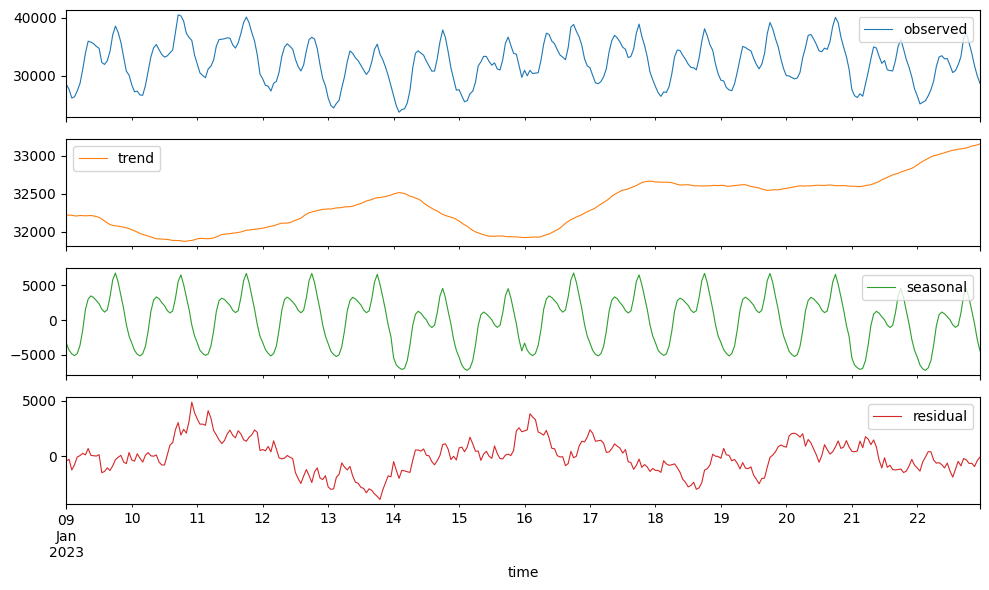

In [30]:
print("standard deviation of each part:")
print(dec.dropna().std().round(0))
print("residual ACF at lags 1, 2, 24:", acf(resid_c.dropna(), 24)[[1, 2, 24]].round(3))
dec.loc["2023-01-09":"2023-01-22"].plot(subplots=True, figsize=(10, 6), lw=0.8)
plt.tight_layout()
plt.show()

**Interview check:** "The residual still has ACF 0.86 at lag 1. What does that tell you?"
Whatever pushed load up this hour is still there next hour (weather, slow noise). A lag-1
term or the weather itself belongs in the model.

## 5. AR(1) via ordinary least squares

An AR(1) is a regression of each value on the previous one: x_t = c + φ·x_t-1.
Six values:

In [31]:
x = pd.Series([8.0, 4.0, 2.0, 1.0, 0.5, 0.25])      # each value is half the previous one
d = pd.DataFrame({"y = x_t": x, "x_t-1": x.shift(1)}).dropna()
d

,y = x_t,x_t-1
1,4.00,8.0
2,2.00,4.0
3,1.00,2.0
4,0.50,1.0
5,0.25,0.5


In [32]:
X = np.column_stack([np.ones(len(d)), d["x_t-1"].values])
y = d["y = x_t"].values
print("X =")
print(X)
print("y =", y)
beta, *_ = np.linalg.lstsq(X, y, rcond=None)
print("c   =", round(beta[0], 3))
print("phi =", round(beta[1], 3))

X =
[[1.  8. ]
 [1.  4. ]
 [1.  2. ]
 [1.  1. ]
 [1.  0.5]]
y = [4.   2.   1.   0.5  0.25]
c   = 0.0
phi = 0.5


φ = 0.5 and c = 0, exactly as the series was built: each value is half the previous one.

### Multi-step forecast from an AR(1)

The forecast h steps ahead is: mean + φ^h × (last value − mean). With φ = 0.5 and the
last deviation from the mean = 8, the deviation halves every step:

In [33]:
phi = 0.5
mean = 100.0
last = 108.0
rows = []
deviation = last - mean
for h in [1, 2, 3, 4]:
    forecast = mean + phi ** h * deviation
    rows.append({"h": h, "phi^h": phi ** h, "forecast": forecast})
pd.DataFrame(rows)

,h,phi^h,forecast
0,1,0.5000,104.0
1,2,0.2500,102.0
2,3,0.1250,101.0
3,4,0.0625,100.5


### On the real data

Fit AR models on the decomposition residual (2022), evaluate on 2023. Each row: lags used,
coefficients, test RMSE, and how much autocorrelation is left in the errors.

In [34]:
resid_all = resid_c.dropna()
train_end = pd.Timestamp("2022-12-31 23:00", tz="UTC")

def fit_ar(series, lags, train_end):
    d = pd.DataFrame({"y": series})
    for k in lags:
        d["lag" + str(k)] = series.shift(k)
    d = d.dropna()
    X = np.column_stack([np.ones(len(d))] + [d["lag" + str(k)].values for k in lags])
    is_train = d.index <= train_end
    beta, *_ = np.linalg.lstsq(X[is_train], d["y"].values[is_train], rcond=None)
    pred = X @ beta
    error = d["y"].values - pred
    return beta, error[~is_train]

rows = []
for lags in [[1], [1, 2], [1, 24], [1, 2, 24, 168]]:
    beta, test_err = fit_ar(resid_all, lags, train_end)
    rows.append({"lags": str(lags), "coefficients": np.round(beta[1:], 3),
                 "test RMSE": np.sqrt(np.mean(test_err ** 2)), "error ACF(1)": acf(test_err, 1)[1]})
pd.DataFrame(rows).round(3)

,lags,coefficients,test RMSE,error ACF(1)
0,[1],[0.866],504.325,0.003
1,"[1, 2]","[0.876, -0.012]",504.315,-0.008
2,"[1, 24]","[0.863, 0.016]",504.109,0.005
3,"[1, 2, 24, 168]","[0.873, -0.012, 0.015, 0.015]",504.125,-0.005


**Interview check:** "Your AR(1) beats persistence at h=1. Does it at h=24?"
φ^24 shrinks the deviation to almost nothing, while the real residual keeps a daily
structure. The fix is a seasonal lag (24, 168) or the weather itself, not a bigger φ.

## 6. Exponential smoothing step by step

level_t = α · x_t + (1 − α) · level_t-1. The forecast for the next value is the current level.
Five values, α = 0.5, starting level = first value:

In [35]:
xs = [10.0, 20.0, 20.0, 20.0, 10.0]
alpha = 0.5
level = xs[0]
rows = [{"t": 0, "x_t": xs[0], "level_t": level, "forecast for t+1": level}]
for t in range(1, len(xs)):
    level = alpha * xs[t] + (1 - alpha) * level
    rows.append({"t": t, "x_t": xs[t], "level_t": level, "forecast for t+1": level})
pd.DataFrame(rows)

,t,x_t,level_t,forecast for t+1
0,0,10.0,10.000,10.000
1,1,20.0,15.000,15.000
2,2,20.0,17.500,17.500
3,3,20.0,18.750,18.750
4,4,10.0,14.375,14.375


At t=1 the level moves halfway from 10 toward 20 (15); at t=2 halfway again (17.5). Bigger α
= faster reaction. pandas does the same recursion with `ewm(alpha=..., adjust=False)`:

In [36]:
pd.Series(xs).ewm(alpha=0.5, adjust=False).mean()

0    10.000
1    15.000
2    17.500
3    18.750
4    14.375
dtype: float64

**Pitfall:** `ewm(...)` defaults to `adjust=True`, which reweights early observations and is
*not* the textbook recursion. `span=` and `halflife=` are other ways to write α.

### On the real data

Choose α by minimising the one-step-ahead squared error on 2022 daily means, then compare
against naive forecasts on 2023.

In [37]:
from scipy.optimize import minimize_scalar

daily = cons.resample("D").mean()
train = daily.loc[:"2022-12-31"]

def one_step_sse(alpha):
    level = train.ewm(alpha=alpha, adjust=False).mean()
    forecast = level.shift(1)                 # level known yesterday
    return ((train - forecast).dropna() ** 2).sum()

result = minimize_scalar(one_step_sse, bounds=(0.01, 0.99), method="bounded")
alpha_best = result.x
print("best alpha:", round(alpha_best, 3), "| converged:", result.success)

best alpha: 0.156 | converged: True


In [38]:
test = daily.loc["2023-01-01":]
ses_forecast = daily.ewm(alpha=alpha_best, adjust=False).mean().shift(1).loc[test.index]
naive_forecast = daily.shift(1).loc[test.index]
weekly_forecast = daily.shift(7).loc[test.index]

def rmse(actual, forecast):
    return np.sqrt(((actual - forecast) ** 2).mean())

pd.Series({
    "naive (yesterday)": rmse(test, naive_forecast),
    "seasonal naive (7 days ago)": rmse(test, weekly_forecast),
    "exponential smoothing": rmse(test, ses_forecast),
}, name="daily RMSE 2023").round(0)

naive (yesterday)              1333.0
seasonal naive (7 days ago)    1181.0
exponential smoothing          1263.0
Name: daily RMSE 2023, dtype: float64

Smoothing loses to "same day last week": the weekly pattern matters more than the level.

## 7. Cross-correlation: which series leads?

Take x with one bump, and y = x shifted one step later.

In [39]:
x = pd.Series([0, 0, 1, 0, 0, 0], dtype=float)
y = x.shift(1).fillna(0)
pd.DataFrame({"x": x, "y": y})

,x,y
0,0.0,0.0
1,0.0,0.0
2,1.0,0.0
3,0.0,1.0
4,0.0,0.0
5,0.0,0.0


`ccf(k) = corr(x_t, y_t+k)`. Line up x with y **k steps later**:

In [40]:
k = 1
pd.DataFrame({"x_t": x[:-k].values, "y_t+1": y[k:].values})

,x_t,y_t+1
0,0.0,0.0
1,0.0,0.0
2,1.0,1.0
3,0.0,0.0
4,0.0,0.0


In [41]:
print("ccf(+1) = corr(x_t, y_t+1) =", round(np.corrcoef(x[:-1], y[1:])[0, 1], 3))
print("ccf(-1) = corr(x_t, y_t-1) =", round(np.corrcoef(x[1:], y[:-1])[0, 1], 3))

ccf(+1) = corr(x_t, y_t+1) = 1.0
ccf(-1) = corr(x_t, y_t-1) = -0.25


The peak is at k = +1: "x now matches y one step later" → **x leads y**.
If you had found the peak at k < 0, y would lead x. Get this sign right before claiming
that anything predicts anything.

### On the real data: temperature vs load

Use residuals (calendar removed) so the shared daily cycle does not dominate. Heating means
colder → higher load, so the correlation is negative and we look for the most negative value.

most negative ccf: -0.18 at k = 0


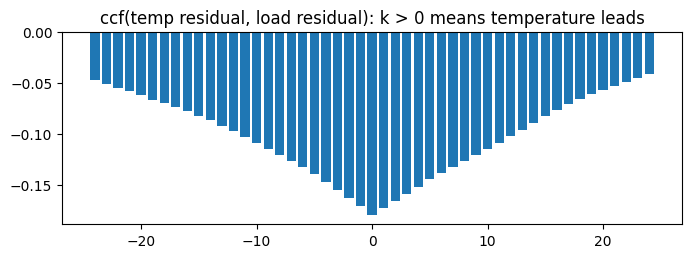

In [42]:
temp_resid = temp - temp.groupby([temp.index.dayofweek, temp.index.hour]).transform("mean")
xt = temp_resid.reindex(resid_all.index).values
yt = resid_all.values

lags = np.arange(-24, 25)
cc = []
for k in lags:
    if k >= 0:
        cc.append(np.corrcoef(xt[:len(xt) - k], yt[k:])[0, 1])
    else:
        cc.append(np.corrcoef(xt[-k:], yt[:len(yt) + k])[0, 1])
cc = np.array(cc)
print("most negative ccf:", round(cc.min(), 3), "at k =", lags[cc.argmin()])
fig, ax = plt.subplots(figsize=(8, 2.5))
ax.bar(lags, cc)
ax.set_title("ccf(temp residual, load residual): k > 0 means temperature leads")
plt.show()

The peak is at k = 0: in this synthetic data load responds within the hour. Real buildings
have thermal inertia, so the peak would sit at k = +2..+6 (temperature leads load).

### Granger-style test: does temperature help predict load?

Compare a regression of load residual on its own lags (restricted) with one that also has
temperature lags (unrestricted). F = ((RSS_r − RSS_u)/q) / (RSS_u/(n − k)).

In [43]:
lag_list = [1, 2, 3, 24]
d = pd.DataFrame({"y": resid_all})
for k in lag_list:
    d["load_lag" + str(k)] = resid_all.shift(k)
    d["temp_lag" + str(k)] = temp_resid.reindex(resid_all.index).shift(k)
d = d.dropna()
load_cols = ["load_lag" + str(k) for k in lag_list]
temp_cols = ["temp_lag" + str(k) for k in lag_list]

X_r = np.column_stack([np.ones(len(d))] + [d[c].values for c in load_cols])
X_u = np.column_stack([np.ones(len(d))] + [d[c].values for c in load_cols + temp_cols])
yv = d["y"].values

b_r, *_ = np.linalg.lstsq(X_r, yv, rcond=None)
b_u, *_ = np.linalg.lstsq(X_u, yv, rcond=None)
rss_r = ((yv - X_r @ b_r) ** 2).sum()
rss_u = ((yv - X_u @ b_u) ** 2).sum()
print("RSS restricted  :", round(rss_r))
print("RSS unrestricted:", round(rss_u))

RSS restricted  : 4375165462
RSS unrestricted: 4323363355


In [44]:
q = len(temp_cols)
k = X_u.shape[1]
n = len(yv)
F = ((rss_r - rss_u) / q) / (rss_u / (n - k))
p_value = 1 - stats.f.cdf(F, q, n - k)
print("F =", round(F, 1), "  p =", p_value)
print("RMSE restricted", round(np.sqrt(rss_r / n), 1), "-> unrestricted", round(np.sqrt(rss_u / n), 1))

F = 51.9   p = 1.1102230246251565e-16
RMSE restricted 502.5 -> unrestricted 499.5


**Pitfall:** "Granger causes" means "helps predict", not "causes". With 17,000 hours almost
anything is significant; report the RMSE change too.

## 8. Spurious regression

Two independent random walks, 8 steps each:

In [45]:
rng = np.random.default_rng(7)
a = pd.Series(rng.normal(size=8).round(2)).cumsum()
b = pd.Series(rng.normal(size=8).round(2)).cumsum()
pd.DataFrame({"a": a, "b": b}).round(2)

,a,b
0,0.00,-0.49
1,0.30,-1.11
2,0.03,-0.62
3,-0.86,-0.26
4,-1.31,-0.15
5,-2.30,-1.08
6,-2.24,-1.11
7,-0.90,-0.41


In [46]:
def slope_t_r2(x, y):
    X = np.column_stack([np.ones(len(x)), x])
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    e = y - X @ beta
    s2 = (e @ e) / (len(y) - 2)
    se = np.sqrt(s2 * np.linalg.inv(X.T @ X)[1, 1])
    r2 = 1 - (e @ e) / ((y - y.mean()) @ (y - y.mean()))
    return round(beta[1], 3), round(beta[1] / se, 2), round(r2, 3)

print("levels     (slope, t, R2):", slope_t_r2(a.values, b.values))
print("differences(slope, t, R2):", slope_t_r2(a.diff().dropna().values, b.diff().dropna().values))

levels     (slope, t, R2): (0.092, 0.59, 0.055)
differences(slope, t, R2): (0.309, 1.02, 0.172)


Even with 8 points the levels can look related. With 2,000 steps the effect is dramatic:

In [47]:
a = np.cumsum(rng.normal(size=2000))
b = np.cumsum(rng.normal(size=2000))
print("levels     (slope, t, R2):", slope_t_r2(a, b))
print("differences(slope, t, R2):", slope_t_r2(np.diff(a), np.diff(b)))

levels     (slope, t, R2): (-0.126, -15.33, 0.105)
differences(slope, t, R2): (0.01, 0.45, 0.0)


The two series are independent by construction, yet the levels regression has a huge t-stat.
In differences the relationship vanishes. Any regression of one trending level on another
(2022 prices on anything that also drifted) has this problem.

In [48]:
p22 = price.loc["2022"].values
t22 = np.arange(len(p22), dtype=float)
print("2022 price on a time trend, levels (slope, t, R2):", slope_t_r2(t22, p22))
print("2022 price on a time trend, changes(slope, t, R2):", slope_t_r2(t22[1:], np.diff(p22)))

2022 price on a time trend, levels (slope, t, R2): (0.006, 43.3, 0.176)
2022 price on a time trend, changes(slope, t, R2): (-0.0, -0.03, 0.0)


## 9. Volatility clustering

Price *changes* may be uncorrelated while their *squares* are correlated: big moves come in
bunches. Eight changes: four small, then four big.

In [49]:
changes = pd.Series([1, -1, 1, -1, 10, -9, 8, -8], dtype=float)
pd.DataFrame({"change": changes, "change^2": changes ** 2})

,change,change^2
0,1.0,1.0
1,-1.0,1.0
2,1.0,1.0
3,-1.0,1.0
4,10.0,100.0
5,-9.0,81.0
6,8.0,64.0
7,-8.0,64.0


In [50]:
print("ACF(1) of changes  :", round(acf(changes, 1)[1], 3))
print("ACF(1) of changes^2:", round(acf(changes ** 2, 1)[1], 3))

ACF(1) of changes  : -0.767
ACF(1) of changes^2: 0.5


The changes alternate sign (negative ACF) but their sizes cluster (positive ACF of squares).
On the real prices:

In [51]:
dp = price.diff().dropna()
print("ACF of price changes,   lags 1, 2, 24:", acf(dp, 24)[[1, 2, 24]].round(3))
print("ACF of squared changes, lags 1, 2, 24:", acf(dp ** 2, 24)[[1, 2, 24]].round(3))
weekly_vol = dp.rolling(24 * 7).std()
print("median weekly std of hourly changes: 2022 =", round(weekly_vol.loc["2022"].median(), 1),
      " 2023 =", round(weekly_vol.loc["2023"].median(), 1))
print("share of total squared change in 2022:", round((dp.loc["2022"] ** 2).sum() / (dp ** 2).sum(), 3))

ACF of price changes,   lags 1, 2, 24: [-0.291  0.038  0.159]
ACF of squared changes, lags 1, 2, 24: [ 0.467 -0.006  0.025]
median weekly std of hourly changes: 2022 = 21.2  2023 = 22.3
share of total squared change in 2022: 0.487


Consequences: one RMSE across 2022–2023 is dominated by the high-volatility year, and
iid confidence intervals are wrong.

## 10. Error vs forecast horizon

The honest summary of any forecasting exercise: RMSE by horizon for naive baselines and
your model. Toy first: a 6-value series and a forecast made at t for t+h.

In [52]:
s = pd.Series([10, 12, 11, 13, 12, 14], dtype=float)
h = 2
pd.DataFrame({"s_t": s, "persistence forecast for t+2": s, "actual at t+2": s.shift(-h)})

,s_t,persistence forecast for t+2,actual at t+2
0,10.0,10.0,11.0
1,12.0,12.0,13.0
2,11.0,11.0,12.0
3,13.0,13.0,14.0
4,12.0,12.0,NaN
5,14.0,14.0,NaN


The persistence forecast for t+2 is just the value at t; the actual is `shift(-2)`. Rows
without an actual (the last two) cannot be scored. RMSE over the rest:

In [53]:
scored = pd.DataFrame({"forecast": s, "actual": s.shift(-h)}).dropna()
print(scored)
print("RMSE:", round(np.sqrt(((scored["actual"] - scored["forecast"]) ** 2).mean()), 3))

   forecast  actual
0      10.0    11.0
1      12.0    13.0
2      11.0    12.0
3      13.0    14.0
RMSE: 1.0


### On the real data

Four forecasts of consumption at t+h made at t, 2023 only:
- persistence: value at t
- seasonal naive: the latest same-hour-of-day value known at t
- calendar model: hour×weekday dummies + trend, fitted on 2022
- calendar + direct AR: the calendar model plus a regression of the residual at t+h on the residual at t and at t−23 (fitted on 2022)

In [54]:
from sklearn.linear_model import LinearRegression

cal = pd.DataFrame(index=cons.index)
cal["trend"] = np.arange(len(cons)) / 8760.0
cal["hd"] = cons.index.dayofweek * 24 + cons.index.hour
X_cal = pd.get_dummies(cal["hd"], prefix="hd", dtype=float)
X_cal["trend"] = cal["trend"]
is_2022 = cons.index.year == 2022
cal_model = LinearRegression().fit(X_cal[is_2022], cons[is_2022])
cal_pred = pd.Series(cal_model.predict(X_cal), index=cons.index)
resid_reg = cons - cal_pred
print("calendar-model residual std:", round(resid_reg.std()))

calendar-model residual std: 2231


In [55]:
rows = []
for h in [1, 6, 12, 24, 48, 168]:
    actual = cons.shift(-h)
    persistence = cons
    seasonal_naive = cons.shift((24 - h) % 24)
    calendar_only = cal_pred.shift(-h)

    # direct AR on the residual: resid_{t+h} ~ resid_t + resid_{t-23}
    d = pd.DataFrame({"y": resid_reg.shift(-h), "r0": resid_reg, "r23": resid_reg.shift(23)}).dropna()
    train = d[d.index.year == 2022]
    Xd = np.column_stack([np.ones(len(train)), train["r0"], train["r23"]])
    bd, *_ = np.linalg.lstsq(Xd, train["y"].values, rcond=None)
    ar_part = bd[0] + bd[1] * resid_reg + bd[2] * resid_reg.shift(23)
    calendar_ar = cal_pred.shift(-h) + ar_part

    score = pd.DataFrame({"actual": actual, "persistence": persistence, "seasonal_naive": seasonal_naive,
                          "calendar_only": calendar_only, "calendar+AR": calendar_ar})
    score = score[score.index.year == 2023].dropna()
    row = {"h": h}
    for c in ["persistence", "seasonal_naive", "calendar_only", "calendar+AR"]:
        row[c] = np.sqrt(((score["actual"] - score[c]) ** 2).mean())
    rows.append(row)
pd.DataFrame(rows).set_index("h").round(0)

,persistence,seasonal_naive,calendar_only,calendar+AR
h,,,,
1,1519.0,1696.0,2567.0,522.0
6,5707.0,1696.0,2567.0,1060.0
12,6072.0,1697.0,2567.0,1256.0
24,1697.0,1697.0,2565.0,1223.0
48,2094.0,2094.0,2564.0,1321.0
168,1591.0,1591.0,2550.0,1425.0


**Interview check:** "Your model beats persistence at h = 1 but barely at h = 168. Is it
useful?" Depends on the decision: a day-ahead trader needs h = 12–36, so quote the metric at
the horizon the decision needs.

## Quick reference

| Concept | By hand |
|---|---|
| ACF(k) | centre with the overall mean; `(xc[k:] * xc[:-k]).sum() / (xc**2).sum()` |
| white-noise band | `±1.96 / sqrt(n)` (only under the null of no autocorrelation) |
| PACF(k) | last coefficient of OLS of x_t on lags 1..k |
| variance ratio | `var(diff(k)) / (k * var(diff(1)))` ≈ 1 for a random walk |
| decomposition | trend = centred rolling mean over one period; seasonal = mean by position; residual = rest |
| AR(p) | `np.linalg.lstsq` on a lag table; check residual ACF |
| h-step AR(1) | `mean + phi**h * (x_t - mean)` |
| exponential smoothing | `s.ewm(alpha=a, adjust=False).mean().shift(1)` |
| ccf(k) | `corr(x[:-k], y[k:])`; peak at k > 0 means x leads y |
| Granger F | `((RSS_r - RSS_u)/q) / (RSS_u/(n-k))` |
| spurious regression | huge t in levels of two random walks; vanishes in differences |
| volatility clustering | ACF of squared changes ≫ ACF of changes |